# Subsample Analysis

This notebook analyzes **how training data size affects model performance** on graph classification tasks.

## Motivation
Understanding the relationship between training set size and model accuracy helps:
- Determine if a model is data-limited (would benefit from more data)
- Compare sample efficiency between different algorithms
- Guide decisions about data collection efforts

## Methodology
1. **Split the dataset** into train/test sets (stratified to preserve class balance)
2. **Generate subsamples** of training data at 10%, 20%, ..., 100%
3. **Train two models** on each subsample:
   - **PathBoost**: Path-based boosting classifier (interpretable, requires categorical node attributes)
   - **GIN**: Graph Isomorphism Network (neural network baseline)
4. **Evaluate** on the held-out test set and plot learning curves

## Expected Output
Learning curves showing accuracy vs. training data percentage for both models.

## 1. Load Dataset and Create Splits

Load a TU Benchmark dataset and create multiple train/test splits for robust evaluation.

**Configuration:**
- `dataset_name`: Choose from TU datasets (e.g., `MUTAG`, `PROTEINS_full`, `AIDS`)
- `n_splits`: Number of independent train/test splits (each uses a different random seed)
- `test_size`: Fraction of data held out for testing (0.1 = 10%)

The splits are created using stratified sampling to ensure each split maintains the original class distribution.

In [1]:
%load_ext autoreload
%autoreload 2
from splitter import create_dataset_splits
import numpy as np

dataset_name = 'PROTEINS_full'  # PROTEINS_full MUTAG SYNTHETIC AIDS

splits, graphs, labels = create_dataset_splits(dataset_name, n_splits=4, test_size=0.1)

Dataset 'PROTEINS_full' already exists at /Users/popcorn/PycharmProjects/Different_datasets/tudataset/tud_benchmark/datasets/PROTEINS_full/PROTEINS_full/raw
Loaded NetworkX graphs from nx_graphs/PROTEINS_full_nx_graphs.pkl


## 2. Analyze Class Balance Across Splits

Verify that stratified splitting preserves class balance in both train and test sets.

**Why this matters:**
- Imbalanced classes can bias accuracy metrics
- Train/test distribution mismatch can cause misleading results
- Consistent class ratios across splits ensure fair comparison

The output shows the percentage of each class (Class 0 / Class 1) in training and test sets for each split.

In [2]:
for i, split in enumerate(splits):
    train_labels = split['train_labels']
    test_labels = split['test_labels']

    _, train_counts = np.unique(train_labels, return_counts=True)
    _, test_counts = np.unique(test_labels, return_counts=True)

    train_pct = train_counts / len(train_labels) * 100
    test_pct = test_counts / len(test_labels) * 100

    print(f"Split {i}: Train {train_pct[0]:.0f}%/{train_pct[1]:.0f}%, Test {test_pct[0]:.0f}%/{test_pct[1]:.0f}%")

Split 0: Train 60%/40%, Test 59%/41%
Split 1: Train 59%/41%, Test 61%/39%
Split 2: Train 60%/40%, Test 60%/40%
Split 3: Train 60%/40%, Test 58%/42%


## 3. Analyze Subsampling

Preview the subsampling process before running the full evaluation.

The `subsample_train()` function creates 10 progressively larger subsets of the training data:
- **10%** → smallest subsample (tests learning from very limited data)
- **20%, 30%, ..., 90%** → intermediate sizes
- **100%** → full training set (baseline performance)

Each subsample uses stratified sampling to maintain class balance, which is critical for:
- Fair comparison across subsample sizes
- Avoiding artifacts from class imbalance at small sample sizes

In [3]:
from splitter import subsample_train

# Analyze subsampling for split 0
subsamples = subsample_train(splits[0]['train_graphs'], splits[0]['train_labels'])

print("Subsampling analysis (Split 0):")
print("-" * 45)
for s in subsamples:
    _, counts = np.unique(s['labels'], return_counts=True)
    pct = counts / len(s['labels']) * 100
    print(f"{s['percentage']:3d}%: {len(s['graphs']):4d} graphs, class balance {pct[0]:.0f}%/{pct[1]:.0f}%")

Subsampling analysis (Split 0):
---------------------------------------------
 10%:  100 graphs, class balance 63%/37%
 20%:  200 graphs, class balance 62%/38%
 30%:  300 graphs, class balance 61%/39%
 40%:  400 graphs, class balance 60%/40%
 50%:  500 graphs, class balance 61%/39%
 60%:  600 graphs, class balance 62%/38%
 70%:  700 graphs, class balance 61%/39%
 80%:  800 graphs, class balance 60%/40%
 90%:  900 graphs, class balance 60%/40%
100%: 1001 graphs, class balance 60%/40%


## 4. Run Training on Subsamples

Run the full evaluation pipeline. This is the **computationally expensive** step.

**For each split and subsample percentage:**
1. Train PathBoost with hyperparameter search (learning rate, path length, iterations)
2. Train GIN with hyperparameter search (layers, hidden dimensions)
3. Evaluate both models on the held-out test set

**Note:** This cell can take significant time depending on:
- Dataset size
- Number of splits (`n_splits`)
- Hyperparameter search grid size

Results are automatically saved to `{dataset_name}_results.json` for later analysis.

In [5]:
from run_evaluation import run_evaluation

results = run_evaluation(dataset=dataset_name, n_splits=5)  # PROTEINS_full

Running evaluation on PROTEINS_full with 5 splits...

Running PathBoost evaluation...
Dataset 'PROTEINS_full' already exists at /Users/popcorn/PycharmProjects/Different_datasets/tudataset/tud_benchmark/datasets/PROTEINS_full/PROTEINS_full/raw
Loaded NetworkX graphs from nx_graphs/PROTEINS_full_nx_graphs.pkl


KeyboardInterrupt: 

## 5. Plot Results

Visualize the learning curves comparing PathBoost and GIN performance.

**Interpreting the plot:**
- **X-axis**: Training data percentage (10% to 100%)
- **Y-axis**: Test accuracy
- **Shaded regions**: Standard deviation across splits (uncertainty)

**Key insights to look for:**
- **Steep early curve**: Model learns quickly from small amounts of data (sample efficient)
- **Flat curve at high %**: Model has saturated; more data won't help much
- **Wide confidence bands**: High variance; results may not be reliable
- **Crossover points**: Where one model starts outperforming the other

You can reload results from a previous run by loading the JSON file directly (useful for analyzing without re-running training).

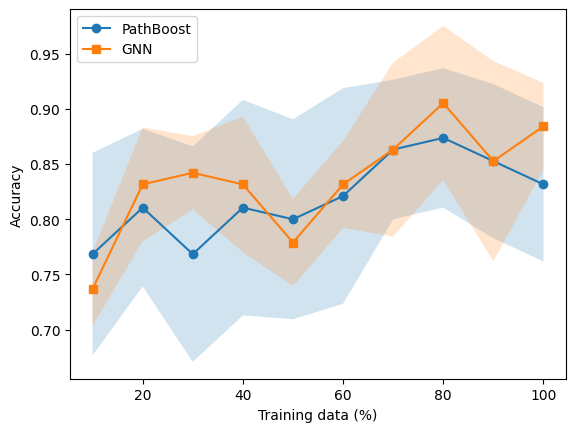

In [8]:
import json
from run_evaluation import plot_results

with open(dataset_name + '_results.json') as f:
    results = json.load(f)

plot_results(results)





## 6. Further Analysis (Optional)

Use this space for additional exploration:
- Compare results across different datasets
- Analyze statistical significance of differences
- Export figures for publication

Dataset 'PROTEINS_full' already exists at /Users/popcorn/PycharmProjects/Different_datasets/tudataset/tud_benchmark/datasets/PROTEINS_full/PROTEINS_full/raw
Loaded NetworkX graphs from nx_graphs/PROTEINS_full_nx_graphs.pkl
Split 0: Train 60%/40%, Test 59%/41%
Split 1: Train 59%/41%, Test 61%/39%
Split 2: Train 60%/40%, Test 60%/40%
Split 3: Train 60%/40%, Test 58%/42%


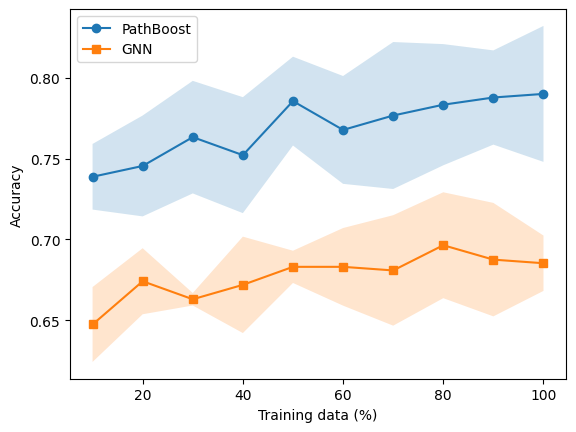

Subsampling analysis (Split 0) for dataset:  PROTEINS_full
---------------------------------------------
 10%:  100 graphs, class balance 63%/37%
 20%:  200 graphs, class balance 62%/38%
 30%:  300 graphs, class balance 61%/39%
 40%:  400 graphs, class balance 60%/40%
 50%:  500 graphs, class balance 61%/39%
 60%:  600 graphs, class balance 62%/38%
 70%:  700 graphs, class balance 61%/39%
 80%:  800 graphs, class balance 60%/40%
 90%:  900 graphs, class balance 60%/40%
100%: 1001 graphs, class balance 60%/40%


In [10]:
dataset_name = 'PROTEINS_full'  # PROTEINS_full MUTAG SYNTHETIC

splits, graphs, labels = create_dataset_splits(dataset_name, n_splits=4, test_size=0.1)

for i, split in enumerate(splits):
    train_labels = split['train_labels']
    test_labels = split['test_labels']

    _, train_counts = np.unique(train_labels, return_counts=True)
    _, test_counts = np.unique(test_labels, return_counts=True)

    train_pct = train_counts / len(train_labels) * 100
    test_pct = test_counts / len(test_labels) * 100

    print(f"Split {i}: Train {train_pct[0]:.0f}%/{train_pct[1]:.0f}%, Test {test_pct[0]:.0f}%/{test_pct[1]:.0f}%")


import json
from run_evaluation import plot_results

with open(dataset_name + '_results.json') as f:
    results = json.load(f)

plot_results(results)
from splitter import subsample_train


# Analyze subsampling for split 0
subsamples = subsample_train(splits[0]['train_graphs'], splits[0]['train_labels'])

print("Subsampling analysis (Split 0) for dataset: ", dataset_name)
print("-" * 45)
for s in subsamples:
    _, counts = np.unique(s['labels'], return_counts=True)
    pct = counts / len(s['labels']) * 100
    print(f"{s['percentage']:3d}%: {len(s['graphs']):4d} graphs, class balance {pct[0]:.0f}%/{pct[1]:.0f}%")